---
title: null
---

<a id="projektionen-lineare-abbildungen"></a>

# Projektionen

Das [**dyadische Produkt**](Kreuz_und_Tensorprodukt.ipynb#tensorprodukt) kann verwendet werden, um Projektionen von Vektoren in Unterräume darzustellen.

### Projektionen

- Projektionen sind grundlegende Werkzeuge in der linearen Algebra und ermöglichen die Abbildung von Vektoren auf spezifische Unterräume.
- Sie finden Anwendung in Optimierung, Datenzerlegung und geometrischen Transformationen.


<!--## 📑 Inhalt

1 [Projektionen als lineare Abbildungen](#projektionen-lineare-abbildungen)  
2 [Projektion auf eine Linie](#projektion-linie)  
3 [Affine Unterräume](#affiner-unterraum)  
4 [Projektion auf eine Hyperebene](#projektion-hyperebene)  
5 [Projektion auf einen Unterraum](#projektion-unterraum)  
6 [Matrixdarstellung der Projektion](#matrixdarstellung-projektion)  
7 [Orthogonalität des Differenzvektors](#orthogonalitaet-differenzvektor)  
8 [Projektion mit beliebiger Basis](#projektion-beliebige-basis)
-->

<a id="orthogonale-projektion"></a>

## Orthogonale Projektion

Eine Projektion eines Vektors

$$
\vec{x}\in\mathbb{R}^n
$$

auf einen Unterraum ist eine Abbildung, die $\vec{x}$ auf einen Vektor im Unterraum abbildet, wobei bei orthogonalen Projektionen der Restvektor orthogonal zum Unterraum ist.

### Orthogonale Projektion auf einen eindimensionalen Unterraum mit Basis $\vec a$

$$
\boxed{
P_{\vec a}(\vec x)
=
\frac{\langle\vec x,\vec a\rangle}{\|\vec a\|^2}\,\vec a
}
$$

In Form des Tensorprodukts:

$$
\boxed{
P_{\vec a}(\vec x)
=
\frac{\vec a\otimes\vec a}{\|\vec a\|^2}\vec x
}
$$

Hierbei ist

$$
\frac{\vec a\otimes\vec a}{\|\vec a\|^2}
$$

die sogenannte **Projektionsmatrix** auf die Richtung $\vec a$.

<a id="eigenschaften-projektionsmatrix"></a>

## Projektionsmatrix: Eigenschaften

Eine Projektionsmatrix $P$ erfüllt:

- **Idempotenz:**

  $$
  P^2=P
  $$

- **Symmetrie:**

  $$
  P^\top=P
  $$

  für orthogonale Projektionen.

### Geometrische Interpretation

Projektionen können geometrisch als „Schatten“ eines Vektors auf eine Linie, Ebene oder einen höherdimensionalen Unterraum verstanden werden.

Beispiel: Projektion auf eine Linie

$$
L=
\left\{
\vec p\in\mathbb R^3:
\vec p=\vec p_0+t\,\vec a,\;
t\in\mathbb R
\right\},
$$

mit einem Stützpunkt $\vec p_0\in\mathbb R^3$ und Richtungsvektor $\vec a\in\mathbb R^3$:

$$
P_{\vec a}(\vec x)
=
\langle\vec x,\vec a\rangle\,\vec a,
\qquad
\text{falls }
\|\vec a\|=1.
$$

Ist $\vec a$ nicht normiert, ist eine Division durch $\|\vec a\|^2$ erforderlich.

<a id="anwendungen-projektionen"></a>

## Anwendungen von Projektionen

- Datenapproximation und Dimensionsreduktion (z. B. Hauptkomponentenanalyse),
- Lösung linearer Gleichungssysteme,
- geometrische Modellierung und Transformationen,
- maschinelles Lernen und Merkmalsraumzerlegungen.

Projektionen bilden die Grundlage für viele fortgeschrittene mathematische und praktische Techniken.

<a id="projektion-linie"></a>

## Projektion auf eine Linie

Gegeben sind die Vektoren

$$
\vec x=
\begin{pmatrix}
2\\
3
\end{pmatrix},
\qquad
\vec a=
\begin{pmatrix}
3\\
1
\end{pmatrix}.
$$

Die Projektionsmatrix lautet:

$$
P_{\vec a}
=
\frac{\vec a\otimes\vec a}{\|\vec a\|^2}
=
\begin{pmatrix}
0.9&0.3\\
0.3&0.1
\end{pmatrix}.
$$

Damit ergibt sich die Projektion:

$$
\boxed{
P_{\vec a}(\vec x)
=
\begin{pmatrix}
2.7\\
0.9
\end{pmatrix}
}
$$

### Interaktive Projektion auf eine Linie

Der Vektor $\vec{x}$ kann mit der Maus verändert werden.

Dabei wird seine orthogonale Projektion auf die durch $\vec{a}$ aufgespannte Gerade automatisch neu berechnet:

$$
P_{\vec a}(\vec{x})
=
\frac{\langle \vec{x},\vec{a}\rangle}
{\|\vec{a}\|^2}\vec{a}.
$$

Ziehe die Spitze von $\vec{x}$ mit der Maus.  
Die Projektion $P_{\vec a}(\vec{x})$ passt sich unmittelbar an.

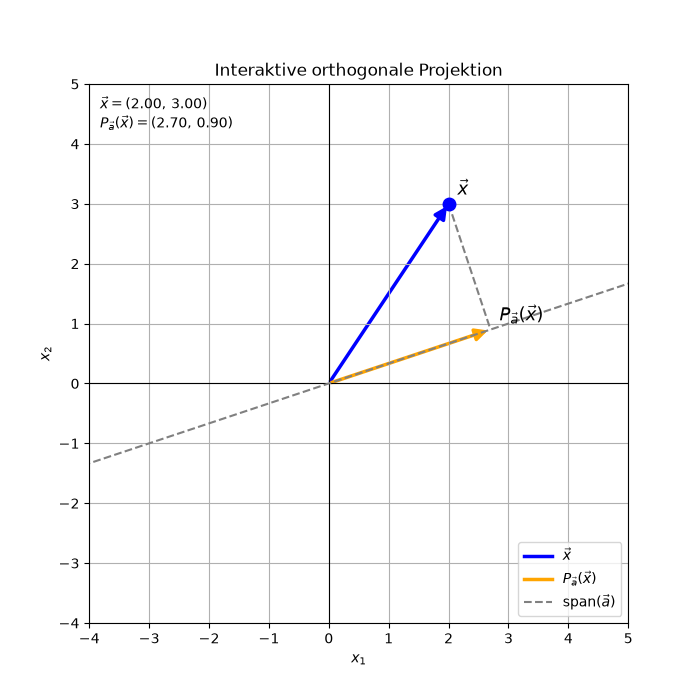

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

# -------------------------------------------------
# Ausgangsdaten
# -------------------------------------------------

a = np.array([3.0, 1.0])
x = np.array([2.0, 3.0])

# -------------------------------------------------
# Projektion berechnen
# -------------------------------------------------

def projektion(x, a):
    return np.dot(x, a) / np.dot(a, a) * a


x_proj = projektion(x, a)

# -------------------------------------------------
# Abbildung
# -------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(-4, 5)
ax.set_ylim(-4, 5)
ax.set_aspect("equal")

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

ax.grid()

# Gerade span(a)
t = np.linspace(-2, 2, 200)
gerade = np.outer(t, a)

ax.plot(
    gerade[:, 0],
    gerade[:, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5
)

# -------------------------------------------------
# Vektor x
# -------------------------------------------------

pfeil_x = FancyArrowPatch(
    (0, 0),
    x,
    arrowstyle="-|>",
    mutation_scale=18,
    linewidth=2.5,
    color="blue"
)

ax.add_patch(pfeil_x)

# -------------------------------------------------
# Projektionsvektor
# -------------------------------------------------

pfeil_proj = FancyArrowPatch(
    (0, 0),
    x_proj,
    arrowstyle="-|>",
    mutation_scale=18,
    linewidth=2.5,
    color="orange"
)

ax.add_patch(pfeil_proj)

# -------------------------------------------------
# Orthogonaler Differenzvektor
# -------------------------------------------------

restlinie, = ax.plot(
    [x[0], x_proj[0]],
    [x[1], x_proj[1]],
    linestyle="--",
    color="gray",
    linewidth=1.5
)

# -------------------------------------------------
# Beweglicher Punkt an der Spitze von x
# -------------------------------------------------

punkt_x, = ax.plot(
    x[0],
    x[1],
    "o",
    color="blue",
    markersize=9
)

# -------------------------------------------------
# Beschriftungen
# -------------------------------------------------

text_x = ax.text(
    x[0] + 0.15,
    x[1] + 0.15,
    r"$\vec{x}$",
    fontsize=13
)

text_proj = ax.text(
    x_proj[0] + 0.15,
    x_proj[1] + 0.15,
    r"$P_{\vec a}(\vec{x})$",
    fontsize=13
)

# Aktuelle Werte anzeigen
info = ax.text(
    0.02,
    0.98,
    "",
    transform=ax.transAxes,
    verticalalignment="top"
)

# -------------------------------------------------
# Legende
# -------------------------------------------------

legende = [
    Line2D(
        [0], [0],
        color="blue",
        linewidth=2.5,
        label=r"$\vec{x}$"
    ),
    Line2D(
        [0], [0],
        color="orange",
        linewidth=2.5,
        label=r"$P_{\vec a}(\vec{x})$"
    ),
    Line2D(
        [0], [0],
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label=r"$\operatorname{span}(\vec a)$"
    )
]

ax.legend(handles=legende, loc="lower right")

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Interaktive orthogonale Projektion")

# -------------------------------------------------
# Aktualisierung der Abbildung
# -------------------------------------------------

def aktualisieren(x_neu):

    global x

    x = np.array(x_neu)

    # Neue Projektion
    x_proj_neu = projektion(x, a)

    # Vektor x aktualisieren
    pfeil_x.set_positions((0, 0), x)

    # Projektion aktualisieren
    pfeil_proj.set_positions((0, 0), x_proj_neu)

    # Restvektor aktualisieren
    restlinie.set_data(
        [x[0], x_proj_neu[0]],
        [x[1], x_proj_neu[1]]
    )

    # Punkt aktualisieren
    punkt_x.set_data([x[0]], [x[1]])

    # Beschriftungen aktualisieren
    text_x.set_position(
        (x[0] + 0.15, x[1] + 0.15)
    )

    text_proj.set_position(
        (x_proj_neu[0] + 0.15, x_proj_neu[1] + 0.15)
    )

    # Zahlenwerte aktualisieren
    info.set_text(
        rf"$\vec{{x}} = ({x[0]:.2f},\,{x[1]:.2f})$"
        "\n"
        rf"$P_{{\vec{{a}}}}(\vec{{x}})"
        rf" = ({x_proj_neu[0]:.2f},\,{x_proj_neu[1]:.2f})$"
    )

    fig.canvas.draw_idle()


aktualisieren(x)

# -------------------------------------------------
# Mausinteraktion
# -------------------------------------------------

wird_gezogen = False


def maus_druecken(event):

    global wird_gezogen

    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    # Abstand der Maus von der Spitze des Vektors
    maus = np.array([event.xdata, event.ydata])

    abstand = np.linalg.norm(maus - x)

    # Nur ziehen, wenn nahe an der Vektorspitze geklickt wird
    if abstand < 0.4:
        wird_gezogen = True


def maus_bewegen(event):

    if not wird_gezogen:
        return

    if event.inaxes != ax:
        return

    if event.xdata is None or event.ydata is None:
        return

    aktualisieren(
        [event.xdata, event.ydata]
    )


def maus_loslassen(event):

    global wird_gezogen
    wird_gezogen = False


# Ereignisse registrieren
fig.canvas.mpl_connect(
    "button_press_event",
    maus_druecken
)

fig.canvas.mpl_connect(
    "motion_notify_event",
    maus_bewegen
)

fig.canvas.mpl_connect(
    "button_release_event",
    maus_loslassen
)

plt.show()

<a id="affiner-unterraum"></a>

## Definition eines affinen Unterraums

Ein **affiner Unterraum**

$$
A\subseteq\mathbb R^n
$$

ist eine Verschiebung eines linearen Unterraums

$$
U\subseteq\mathbb R^n
$$

um einen festen Punkt $\vec p\in\mathbb R^n$:

$$
\boxed{
A=
\{\vec p+\vec u\mid\vec u\in U\}.
}
$$

Der Punkt $\vec p$ heißt **Aufpunkt**, und $U$ wird der **Richtungsraum** des affinen Unterraums genannt.

### Eigenschaften

- Ein affiner Unterraum ist kein linearer Unterraum, es sei denn, der Aufpunkt ist der Nullvektor:

  $$
  \vec p=\vec0.
  $$

- Der Richtungsraum $U$ bestimmt die Richtung und Dimension des affinen Unterraums.

<a id="definition-ebene"></a>

## Definition der Ebene

Eine **Ebene** ist ein zweidimensionaler affiner Unterraum im dreidimensionalen Raum $\mathbb R^3$.

Sie kann durch folgende Darstellungen beschrieben werden.

### Parametrische Darstellung

$$
\boxed{
\vec p
=
\vec p_0
+
\lambda_1\vec v_1
+
\lambda_2\vec v_2
}
$$

wobei:

- $\vec p_0\in\mathbb R^3$: ein Punkt auf der Ebene,
- $\vec v_1,\vec v_2\in\mathbb R^3$: zwei linear unabhängige Tangentenvektoren,
- $\lambda_1,\lambda_2\in\mathbb R$: freie Parameter.

<a id="punkt-normalen-form"></a>

## Punkt-Normalen-Form der Ebene

Die Punkt-Normalen-Form beschreibt die Ebene unter Verwendung eines Punkts $\vec p_0$ auf der Ebene und eines Normalenvektors $\vec n$, der orthogonal zur Ebene steht.

Die Gleichung lautet:

$$
\boxed{
\langle\vec n,\vec p-\vec p_0\rangle=0
}
$$

wobei:

- $\vec n=(n_1,n_2,n_3)$: der Normalenvektor,
- $\vec p_0=(x_0,y_0,z_0)$: ein Punkt auf der Ebene,
- $\vec p=(x,y,z)$: ein beliebiger Punkt auf der Ebene.

Die Punkt-Normalen-Form basiert auf der orthogonalen Beziehung:

$$
\vec n\perp(\vec p-\vec p_0).
$$

<a id="normalenvektor"></a>

## Der Normalenvektor $\vec n$

### Eigenschaften des Normalenvektors

- Der Normalenvektor $\vec n$ steht senkrecht auf der Ebene.
- $\vec n$ ist orthogonal zu den beiden Tangentenvektoren $\vec v_1$ und $\vec v_2$.
- Die orthogonalen Bedingungen lauten:

$$
\langle\vec n,\vec v_1\rangle=0
\qquad\text{und}\qquad
\langle\vec n,\vec v_2\rangle=0.
$$

### Bestimmung von $\vec n$

Das Gleichungssystem

$$
n_1v_{11}+n_2v_{12}+n_3v_{13}=0,
$$

$$
n_1v_{21}+n_2v_{22}+n_3v_{23}=0
$$

wird gelöst, indem eine Komponente, z. B. $n_3$, festgelegt wird.

Alternativ kann $\vec n$ durch das Kreuzprodukt berechnet werden:

$$
\boxed{
\vec n=\vec v_1\times\vec v_2.
}
$$

<a id="allgemeine-ebene"></a>

## Allgemeine Gleichung der Ebene

Die **allgemeine Gleichung der Ebene** ist eine explizite lineare Gleichung in den Koordinaten $x$, $y$ und $z$.

$$
\boxed{
n_1x+n_2y+n_3z=d
}
$$

wobei:

- die Koeffizienten $n_1,n_2,n_3$ die Komponenten des Normalenvektors sind,
- die rechte Seite gegeben ist durch:

$$
d=\langle\vec n,\vec p_0\rangle.
$$

<a id="normalisierter-normalenvektor"></a>

## Normalisierter Normalenvektor $\vec n_0$

Der **Einheitsnormalenvektor** $\vec n_0$ hat die Länge $1$:

$$
\|\vec n_0\|=1.
$$

$\vec n_0$ wird aus dem Normalenvektor $\vec n$ berechnet durch:

$$
\boxed{
\vec n_0
=
\frac{\vec n}{\|\vec n\|}
}
$$

### Abstand der Ebene $E$ zum Ursprung

$$
d(E,\vec O)
=
\frac{d}{\|\vec n\|}
=
\frac{\langle\vec n,\vec p_0\rangle}{\|\vec n\|}
=
\frac{
n_1x_0+n_2y_0+n_3z_0
}{
\sqrt{n_1^2+n_2^2+n_3^2}
},
$$

wobei $x_0,y_0,z_0$ die Koordinaten von $\vec p_0$ sind und $\vec p_0$ ein beliebiger Punkt auf der Ebene ist.

<a id="hyperebene"></a>

## Definition einer Hyperebene (Hyperplane)

Eine **Hyperebene** $H$ im $n$-dimensionalen Raum $\mathbb R^n$ ist ein affiner Unterraum der Dimension $n-1$.

Sie wird durch eine lineare Gleichung der Form beschrieben:

$$
\boxed{
H=
\{
\vec x\in\mathbb R^n
\mid
\langle\vec n,\vec x\rangle=d
\}
}
$$

wobei:

- $\vec n\in\mathbb R^n\setminus\{0\}$ der Normalenvektor der Hyperebene ist,
- $d\in\mathbb R$ ein Skalar ist, der den Abstand der Hyperebene vom Ursprung bestimmt:

$$
d(H,\vec O)
=
\frac{d}{\|\vec n\|}.
$$

<a id="projektion-hyperebene"></a>

## Projektion auf eine Hyperebene

- $H$: Hyperebene
- $P_{\vec n_0}\vec x$: Projektion von $\vec x$ auf $\vec n_0$
- $P_H\vec x$: Projektion von $\vec x$ auf $H$






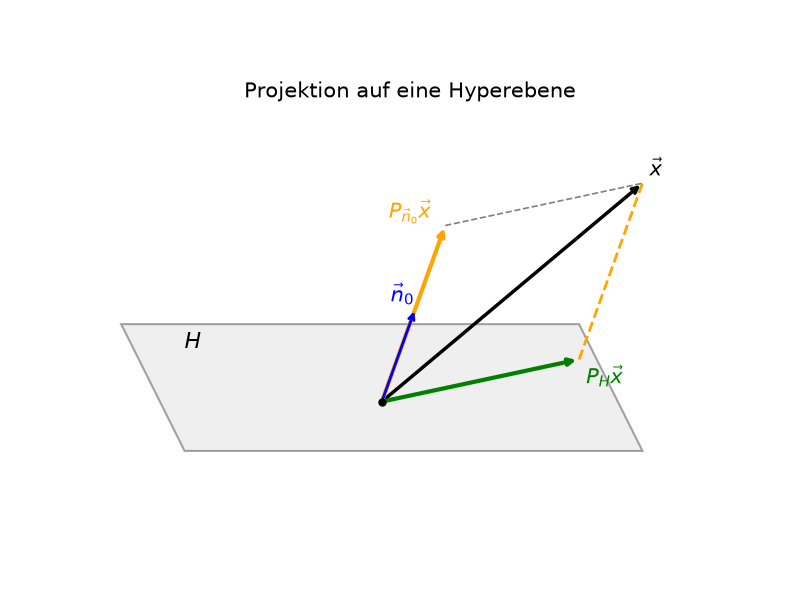

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

# -------------------------------------------------
# Punkte
# -------------------------------------------------

O = np.array([0.0, 0.0])

# Projektion von x auf H
PHx = np.array([2.8, 0.6])

# Projektion von x auf die Normalenrichtung n_0
Pn0x = np.array([0.9, 2.5])

# Zerlegung:
# x = P_H x + P_{n_0} x
x = PHx + Pn0x

# -------------------------------------------------
# Hyperebene H
# schematisch als geneigte Fläche
# -------------------------------------------------

ebene = Polygon(
    [
        (-2.8, -0.7),
        (3.7, -0.7),
        (2.8, 1.1),
        (-3.7, 1.1)
    ],
    closed=True,
    facecolor="lightgray",
    edgecolor="black",
    alpha=0.35,
    linewidth=1.5
)

ax.add_patch(ebene)

ax.text(
    -2.8,
    0.75,
    r"$H$",
    fontsize=16
)

# -------------------------------------------------
# Vektor x
# -------------------------------------------------

ax.annotate(
    "",
    xy=x,
    xytext=O,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2.5,
        color="black"
    )
)

ax.text(
    x[0] + 0.1,
    x[1] + 0.1,
    r"$\vec{x}$",
    fontsize=15
)

# -------------------------------------------------
# Projektion P_H x
# -------------------------------------------------

ax.annotate(
    "",
    xy=PHx,
    xytext=O,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=3,
        color="green"
    )
)

ax.text(
    PHx[0] + 0.1,
    PHx[1] - 0.35,
    r"$P_H\vec{x}$",
    fontsize=15,
    color="green"
)

# -------------------------------------------------
# Projektion P_{n_0} x
# vom Ursprung aus
# -------------------------------------------------

ax.annotate(
    "",
    xy=Pn0x,
    xytext=O,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=3,
        color="orange"
    )
)

ax.text(
    Pn0x[0] - 0.8,
    Pn0x[1] + 0.1,
    r"$P_{\vec{n}_0}\vec{x}$",
    fontsize=15,
    color="orange"
)

# -------------------------------------------------
# Normalenrichtung n_0
# -------------------------------------------------

n0 = Pn0x / np.linalg.norm(Pn0x)
n0_ende = 1.4 * n0

ax.annotate(
    "",
    xy=n0_ende,
    xytext=O,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2,
        color="blue"
    )
)

ax.text(
    n0_ende[0] - 0.35,
    n0_ende[1] + 0.1,
    r"$\vec{n}_0$",
    fontsize=15,
    color="blue"
)

# -------------------------------------------------
# Verschobener orthogonaler Anteil
#
# Dieser zeigt:
# x - P_H x = P_{n_0} x
# -------------------------------------------------

ax.plot(
    [PHx[0], x[0]],
    [PHx[1], x[1]],
    linestyle="--",
    linewidth=2,
    color="orange"
)

# Hilfslinie für das Parallelogramm
ax.plot(
    [Pn0x[0], x[0]],
    [Pn0x[1], x[1]],
    linestyle="--",
    linewidth=1.2,
    color="gray"
)

# -------------------------------------------------
# Ursprung
# -------------------------------------------------

ax.scatter(
    0,
    0,
    color="black",
    s=25,
    zorder=5
)

# -------------------------------------------------
# Darstellung
# -------------------------------------------------

ax.set_xlim(-4, 4.8)
ax.set_ylim(-1.4, 4.2)

ax.set_aspect("equal")
ax.axis("off")

ax.set_title(
    "Projektion auf eine Hyperebene",
    fontsize=15
)

plt.show()

## Matrixdarstellung der Projektion auf $H$

$$
\begin{aligned}
P_H\vec x
&=
\vec x-P_{\vec n_0}\vec x\\
&=
\vec x-\langle\vec x,\vec n_0\rangle\,\vec n_0\\
&=
\vec x-(\vec n_0\otimes\vec n_0)\vec x\\
&=
(\vec I-\vec n_0\otimes\vec n_0)\vec x.
\end{aligned}
$$

Mit der Einheitsmatrix $I_{n\times n}$:

$$
I_{n\times n}
=
\begin{pmatrix}
1&0&\cdots&0\\
0&1&\cdots&0\\
\vdots&\vdots&\ddots&\vdots\\
0&0&\cdots&1
\end{pmatrix}.
$$

<a id="projektion-unterraum"></a>

## Projektion auf einen Unterraum

### Ziel

Wir möchten einen Vektor

$$
\vec x\in\mathbb R^n
$$

auf einen Unterraum

$$
U\subset\mathbb R^n
$$

projizieren.

Der Unterraum $U$ wird durch eine **Orthonormalbasis**

$$
\{\vec u_1,\vec u_2,\ldots,\vec u_k\}
$$

mit

$$
\langle\vec u_i,\vec u_j\rangle
=
\begin{cases}
1,&\text{falls }i=j,\\
0,&\text{falls }i\neq j
\end{cases}
$$

aufgespannt.

### Wichtig

- Jede Projektion auf $U$ kann als Summe der Projektionen auf die **orthonormalen Basisvektoren** von $U$ dargestellt werden.
- Diese Darstellung gilt nur, wenn die Basis **orthonormal** ist. Andernfalls ist eine solche einfache Darstellung nicht möglich.
- Dies führt zu einer kompakten Darstellung mit Hilfe von Tensorprodukten und Matrizen.

## Projektion auf einen Basisvektor

Sei $\vec u_i$ ein normalisierter Basisvektor:

$$
\|\vec u_i\|=1.
$$

Die Projektion von $\vec x$ auf $\vec u_i$ ist:

$$
\boxed{
P_{\vec u_i}(\vec x)
=
\langle\vec x,\vec u_i\rangle\,\vec u_i
=
(\vec u_i\otimes\vec u_i)\vec x.
}
$$

Das Tensorprodukt

$$
\vec u_i\otimes\vec u_i
$$

repräsentiert die Projektionsmatrix auf $\vec u_i$.

**Eigenschaften:** Die Projektion ist linear und orthogonal.

## Lineare und orthogonale Projektion

### Was bedeutet linear?

Eine Projektion $P_{\vec u_i}$ ist **linear**, wenn für beliebige Vektoren

$$
\vec x,\vec y\in\mathbb R^n
$$

und Skalare

$$
\alpha,\beta\in\mathbb R
$$

gilt:

$$
P_{\vec u_i}(\alpha\vec x+\beta\vec y)
=
\alpha P_{\vec u_i}(\vec x)
+
\beta P_{\vec u_i}(\vec y).
$$

Die Projektion wird durch eine lineare Abbildung dargestellt:

$$
P_{\vec u_i}(\vec x)
=
(\vec u_i\otimes\vec u_i)\vec x.
$$

### Was bedeutet orthogonal?

Die Projektion $P_{\vec u_i}(\vec x)$ ist **orthogonal**, wenn der Differenzvektor zwischen $\vec x$ und seiner Projektion orthogonal zu $\vec u_i$ ist:

$$
\boxed{
\vec r
=
\vec x-P_{\vec u_i}(\vec x)
\qquad\text{mit}\qquad
\langle\vec r,\vec u_i\rangle=0.
}
$$

Dies bedeutet, dass der Differenzvektor $\vec r$ senkrecht auf $\vec u_i$ steht.

## Projektion auf einen Unterraum

Der Unterraum $U$ wird durch eine **Orthonormalbasis**

$$
\{\vec u_1,\vec u_2,\ldots,\vec u_k\}
$$

beschrieben.

Die Projektion von $\vec x$ auf $U$ ist die Summe der Projektionen auf die Basisvektoren:

$$
\boxed{
P_U(\vec x)
=
\sum_{i=1}^k
(\vec u_i\otimes\vec u_i)\vec x.
}
$$

Die Matrixdarstellung lautet:

$$
\boxed{
P_U
=
\sum_{i=1}^k
(\vec u_i\otimes\vec u_i).
}
$$

<a id="matrixdarstellung-projektion"></a>

## Matrixdarstellung der Projektion

Die Orthonormalbasisvektoren werden als Spalten in die Matrix $\vec A$ geschrieben:

$$
\vec A
=
\begin{pmatrix}
\vec u_1&\vec u_2&\cdots&\vec u_k
\end{pmatrix}
\in\mathbb R^{n\times k}.
$$

Die Projektion wird als Matrixmultiplikation dargestellt:

$$
\boxed{
P_U
=
\vec A\vec A^\top.
}
$$

Dabei gilt:

$$
\boxed{
\vec A\vec A^\top
=
\sum_{i=1}^k
(\vec u_i\otimes\vec u_i).
}
$$

## Berechnung von $\vec A\vec A^\top$

Gegeben ist die Matrix $\vec A$ mit den Spaltenvektoren:

$$
\vec A
=
\begin{pmatrix}
u_{11}&u_{12}\\
u_{21}&u_{22}
\end{pmatrix},
$$

$$
\vec u_1
=
\begin{pmatrix}
u_{11}\\
u_{21}
\end{pmatrix},
\qquad
\vec u_2
=
\begin{pmatrix}
u_{12}\\
u_{22}
\end{pmatrix}.
$$

Dann gilt:

$$
\vec A\vec A^\top
=
\begin{pmatrix}
u_{11}&u_{12}\\
u_{21}&u_{22}
\end{pmatrix}
\begin{pmatrix}
u_{11}&u_{21}\\
u_{12}&u_{22}
\end{pmatrix}
$$

und damit:

$$
\boxed{
\vec A\vec A^\top
=
\begin{pmatrix}
u_{11}^2+u_{12}^2&
u_{11}u_{21}+u_{12}u_{22}\\
u_{11}u_{21}+u_{12}u_{22}&
u_{21}^2+u_{22}^2
\end{pmatrix}.
}
$$

## Berechnung von $\sum_{i=1}^k(\vec u_i\otimes\vec u_i)$

Für den ersten Basisvektor:

$$
\vec u_1\otimes\vec u_1
=
\begin{pmatrix}
u_{11}\\
u_{21}
\end{pmatrix}
\begin{pmatrix}
u_{11}&u_{21}
\end{pmatrix}
=
\begin{pmatrix}
u_{11}^2&u_{11}u_{21}\\
u_{11}u_{21}&u_{21}^2
\end{pmatrix}.
$$

Für den zweiten Basisvektor:

$$
\vec u_2\otimes\vec u_2
=
\begin{pmatrix}
u_{12}\\
u_{22}
\end{pmatrix}
\begin{pmatrix}
u_{12}&u_{22}
\end{pmatrix}
=
\begin{pmatrix}
u_{12}^2&u_{12}u_{22}\\
u_{12}u_{22}&u_{22}^2
\end{pmatrix}.
$$

Die Summe ergibt:

$$
\sum_{i=1}^2
(\vec u_i\otimes\vec u_i)
=
\begin{pmatrix}
u_{11}^2+u_{12}^2&
u_{11}u_{21}+u_{12}u_{22}\\
u_{11}u_{21}+u_{12}u_{22}&
u_{21}^2+u_{22}^2
\end{pmatrix}.
$$

Damit gilt:

$$
\boxed{
\vec A\vec A^\top
=
\sum_{i=1}^2
(\vec u_i\otimes\vec u_i).
}
$$

## Mögliche Darstellungen der Projektion auf den Unterraum

$$
\begin{aligned}
P_{\vec A}\vec x
&=
\sum_{i=1}^k
\langle\vec u_i,\vec x\rangle\vec u_i\\
&=
\sum_{i=1}^k
(\vec u_i\otimes\vec u_i)\vec x\\
&=
\sum_{i=1}^k
(\vec u_i\vec u_i^\top)\vec x\\
&=
\vec A\vec A^\top\vec x.
\end{aligned}
$$

<a id="orthogonalitaet-differenzvektor"></a>

## Orthogonalität des Differenzvektors

Bei einer orthogonalen Projektion ist die Projektionsmatrix definiert als:

$$
\vec P
=
\mathbf A\mathbf A^\top,
$$

wobei die Spalten von

$$
\mathbf A\in\mathbb R^{n\times k}
$$

eine Orthonormalbasis des Unterraums $U$ mit

$$
\dim U=k
$$

bilden.

Der Differenzvektor ist gegeben durch:

$$
\boxed{
\vec r
=
\vec x-\vec P\vec x
=
\vec x-\mathbf A\mathbf A^\top\vec x.
}
$$

Der Differenzvektor

$$
\vec r\in\mathbb R^n
$$

ist definiert als:

$$
\vec r
=
\vec x-\vec P\vec x,
\qquad
P=\mathbf A\mathbf A^\top.
$$

Ziel ist zu zeigen, dass $\vec r$ orthogonal zum Unterraum $U$ der Dimension $k$ ist, der von den Spalten der Matrix

$$
\mathbf A\in\mathbb R^{n\times k}
$$

aufgespannt wird.

### Berechnung

$$
\begin{aligned}
\mathbf A^\top\vec r
&=
\mathbf A^\top
(\vec x-\mathbf A\mathbf A^\top\vec x)\\
&=
\mathbf A^\top\vec x
-
\mathbf A^\top\mathbf A\mathbf A^\top\vec x.
\end{aligned}
$$

Da

$$
\vec A^\top\vec A=\vec I_k
$$

(Identität in den Unterraum $U$), folgt

$$
\mathbf A^\top\mathbf A\mathbf A^\top
=
\mathbf A^\top.
$$

Damit gilt:

$$
\mathbf A^\top\vec r
=
\mathbf A^\top\vec x
-
\mathbf A^\top\vec x
=
\vec0.
$$

### Ergebnis

- Der Restvektor

  $$
  \vec r
  =
  \vec x-\mathbf A\mathbf A^\top\vec x
  $$

  ist orthogonal zu allen Spalten von $\mathbf A$.

- Damit liegt $\vec r$ im orthogonalen Komplement des Unterraums $U$.

<a id="projektion-beliebige-basis"></a>

## Projektion mit beliebiger Basis

### Gegeben

- $\vec a_1,\vec a_2,\ldots,\vec a_k$: Basis von

  $$
  U\subset\mathbb R^n,
  $$

  jedoch **keine Orthonormalbasis**.

- Die Matrix $A$ enthält die Basisvektoren als Spalten:

$$
\vec A
=
\begin{pmatrix}
\vec a_1&\vec a_2&\cdots&\vec a_k
\end{pmatrix},
\qquad
A\in\mathbb R^{(n,k)}.
$$

### Projektion auf den Unterraum $U$

Der von den Basisvektoren $\{\vec a_i\}$ aufgespannte Unterraum $U$ wird durch eine Linearkombination der Basisvektoren beschrieben.

Die Projektion eines Vektors

$$
\vec x\in\mathbb R^n
$$

auf $U$ ist gegeben durch:

$$
\boxed{
P_{\vec A}\vec x
=
\vec A\boldsymbol{\lambda}
}
$$

wobei $\boldsymbol{\lambda}$ die Koeffizienten der Linearkombination sind.

## Projektion mit beliebiger Basis

Die Projektion eines Vektors

$$
\vec x\in\mathbb R^n
$$

auf den Unterraum $U$ ist durch

$$
P_{\vec A}\vec x
=
\vec A\boldsymbol{\lambda}
$$

gegeben.

Damit die Projektion tatsächlich im Unterraum $U$ liegt, muss der projizierte Vektor eine Linearkombination der Spalten von $\vec A$ sein, da diese Spalten den Unterraum $U$ aufspannen.

Nur so wird sichergestellt, dass die Projektion vollständig innerhalb des Unterraums bleibt.

Die Koeffizienten $\boldsymbol{\lambda}$ bestimmen, wie die einzelnen Spalten von $\vec A$ gewichtet werden, um die Projektion zu erzeugen.

## Orthogonalität des Differenzvektors

Wir konstruieren die Projektion explizit als orthogonale Projektion. Anschließend überprüfen wir ihre Eigenschaften, Idempotenz und Symmetrie, um zu zeigen, dass es sich um eine gültige Projektion handelt.

Der Differenzvektor

$$
\vec r
=
\vec x-\vec A\boldsymbol{\lambda}
$$

ist orthogonal zu $U$:

$$
\vec r
=
\vec x-P_{\vec A}\vec x
\qquad
\text{mit}
\qquad
\vec r\perp\vec a_i
\quad
\forall i=1,\ldots,k.
$$

Dies bedeutet, dass der Differenzvektor senkrecht zu jedem Basisvektor $\vec a_i$ steht.

Der Vektor $\vec x$ lässt sich in zwei Anteile zerlegen:

$$
\boxed{
\vec x
=
P_{\vec A}\vec x+\vec r,
\qquad
\vec r\perp U.
}
$$

<a id="herleitung-projektion"></a>

## Herleitung der Projektion

### Orthogonalitätsbedingung

Der Differenzvektor

$$
\vec r
=
\vec x-\mathbf A\boldsymbol{\lambda}
$$

muss orthogonal zu jedem Basisvektor $\vec a_i$ des Unterraums $U$ sein:

$$
\vec x-\mathbf A\boldsymbol{\lambda}
\perp
\vec a_i,
\qquad
\forall i=1,\ldots,k.
$$

Für jeden Basisvektor $\vec a_i$ gilt daher:

$$
\vec a_i^\top
(\vec x-\mathbf A\boldsymbol{\lambda})
=
0,
\qquad
\forall i=1,\ldots,k.
$$

Zusammenfassung in Matrixform:

$$
\boxed{
\mathbf A^\top
(\vec x-\mathbf A\boldsymbol{\lambda})
=
0.
}
$$

### Lösung für $\boldsymbol{\lambda}$

Umstellen ergibt:

$$
\mathbf A^\top\mathbf A\boldsymbol{\lambda}
=
\mathbf A^\top\vec x.
$$

Die Lösung für die Koeffizienten lautet:

$$
\boxed{
\boldsymbol{\lambda}
=
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top\vec x.
}
$$

### Zusammenfassung

Die Projektion wird berechnet durch:

$$
P_{\vec A}\vec x
=
\mathbf A\boldsymbol{\lambda}.
$$

Mit $\boldsymbol{\lambda}$ aus obiger Lösung:

$$
\boxed{
P_{\vec A}\vec x
=
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top\vec x.
}
$$

Damit lautet die Projektionsmatrix:

$$
\boxed{
P_{\vec A}
=
\vec A
(\vec A^\top\vec A)^{-1}
\vec A^\top.
}
$$

## Überprüfung der Eigenschaften einer Projektion

Um zu zeigen, dass $P_{\vec A}$ tatsächlich eine Projektion ist, müssen die folgenden Eigenschaften überprüft werden:

1. **Idempotenz**

   $$
   P_{\vec A}^2
   =
   P_{\vec A}
   $$

2. **Symmetrie**

   $$
   P_{\vec A}^\top
   =
   P_{\vec A}
   $$

Diese Eigenschaften garantieren, dass $P_{\vec A}$ eine orthogonale Projektion darstellt.

<a id="idempotenz-projektionsmatrix"></a>

## Idempotenz der Projektionsmatrix

Eine Matrix $P$ ist **idempotent**, wenn gilt:

$$
P^2=P.
$$

Sei die Projektionsmatrix:

$$
P_{\vec A}
=
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top.
$$

Berechnen wir $P_{\vec A}^2$:

$$
P_{\vec A}^2
=
\left[
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top
\right]
\left[
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top
\right].
$$

Gruppieren der Terme:

$$
P_{\vec A}^2
=
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
[\mathbf A^\top\mathbf A]
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top.
$$

Da

$$
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top\mathbf A
=
\mathbf I,
$$

ergibt sich:

$$
\boxed{
P_{\vec A}^2
=
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top
=
P_{\vec A}.
}
$$

<a id="symmetrie-projektionsmatrix"></a>

## Symmetrie der Projektionsmatrix

Sei die Projektionsmatrix:

$$
P_{\vec A}
=
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top.
$$

Berechnen wir die Transponierte:

$$
P_{\vec A}^\top
=
\left[
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top
\right]^\top.
$$

Transponieren eines Matrixprodukts liefert:

$$
P_{\vec A}^\top
=
\mathbf A^\top{}^\top
\left[
(\mathbf A^\top\mathbf A)^{-1}
\right]^\top
\mathbf A^\top.
$$

Da

$$
(\mathbf A^\top\mathbf A)^{-1}
$$

symmetrisch ist,

$$
(\mathbf A^\top\mathbf A)^{-1}
=
(\mathbf A^\top\mathbf A)^{-\top},
$$

und

$$
\mathbf A^\top{}^\top
=
\mathbf A,
$$

ergibt sich:

$$
\boxed{
P_{\vec A}^\top
=
\mathbf A
(\mathbf A^\top\mathbf A)^{-1}
\mathbf A^\top
=
P_{\vec A}.
}
$$